Human in the Loop

In [9]:
import os
from langchain.chat_models import init_chat_model

os.environ["GOOGLE_API_KEY"]=os.getenv("GOOGLE_API_KEY")

model_name="google_genai:gemini-2.5-flash"
llm=init_chat_model(model_name)

import od

In [10]:
from typing import Annotated
from langchain_tavily import TavilySearch
from langchain_core.tools import tool
from typing_extensions import TypedDict
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START,END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.types import Command, interrupt

class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder=StateGraph(State)



In [11]:
@tool
def human(query:str)->str:
    """request assistance from a human"""
    response=interrupt({"query":query})
    return response["data"]



tool=TavilySearch(max_results=2)
tools=[tool,human]
llm_with_tools=llm.bind_tools(tools)

In [12]:
def chatbot(state:State):
    message= llm_with_tools.invoke(state["messages"])

    return {"messages":[message]}



In [13]:
graph_builder.add_node("chatbot" , chatbot)
tool_node=ToolNode(tools=tools)
graph_builder.add_node("tools",tool_node)
memory=MemorySaver()

graph_builder.add_conditional_edges("chatbot",tools_condition)
graph_builder.add_edge("tools","chatbot")
graph_builder.add_edge(START,"chatbot")

graph=graph_builder.compile(checkpointer=memory)

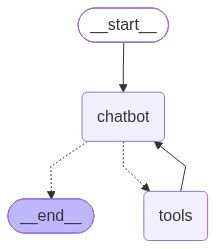

In [14]:
graph

In [19]:
user_input="i need some guidance for building an ai agent. could you request assistance for me?"
config={"configurable":{"thread_id":"1"}}

events=graph.stream(
    {"messages":user_input},
    config,
    stream_mode="values",
)

for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

i need some guidance for building an ai agent. could you request assistance for me?


ChatGoogleGenerativeAIError: Error calling model 'gemini-2.5-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash\nPlease retry in 38.443721024s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeT

In [16]:
human_response=("we the experts are here to help ! we d recommend you to check out Langgraph to build your agent. Its much more reliable and extensible than autnomous agents"
)

human_command=Command(resume={"data":human_response})

events= graph.stream(human_command, config, stream_mode="values")
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()


================================== Ai Message ==================================
Tool Calls:
  human (4009b15f-a747-47d6-9731-54684c02b6be)
 Call ID: 4009b15f-a747-47d6-9731-54684c02b6be
  Args:
    query: The user needs guidance for building an AI agent.
================================= Tool Message =================================
Name: human

we the experts are here to help ! we d recommend you to check out Langgraph to build your agent. Its much more reliable and extensible than autnomous agents
================================== Ai Message ==================================

[{'type': 'text', 'text': 'The experts recommend checking out Langgraph to build your AI agent. They mentioned it is much more reliable and extensible than autonomous agents.', 'extras': {'signature': 'CocDARFNMg+k71G9g0ZRHncPq45S6JN8cF7pxikVZOggwBlJLNGMytvVOtce4SlXGOsEIRxL2VoaJg35FYAxeXAMZ12+NBLSAQsihu/TX2UBq2ShmHtyIR4MtwB3RL5DMWt4dUApsQLQgwh+MBytC81PIGggn39Td2NFA8ks8Ir9W11md1U5dCY9sR3jtrQ/y+JEus3wqTt5KEVUs